## Lecture session for Confidence Intervals

**STATISTICS**

In [1]:
#Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Build a 95% and 80% confidence intervals hat will serve as an estimate for the average age of maternal mothers in the unknown population**

In [2]:
#Reading the .csv file

df = pd.read_csv('baby.csv')
df.head()

,Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
0,120,284,27,62,100,False
1,113,282,33,64,135,False
2,128,279,28,64,115,True
3,108,282,23,67,125,True
4,136,286,25,62,93,False


In [3]:
#Getting information about the columns in the dataframe using the info() function

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Birth Weight               1174 non-null   int64
 1   Gestational Days           1174 non-null   int64
 2   Maternal Age               1174 non-null   int64
 3   Maternal Height            1174 non-null   int64
 4   Maternal Pregnancy Weight  1174 non-null   int64
 5   Maternal Smoker            1174 non-null   bool 
dtypes: bool(1), int64(5)
memory usage: 47.1 KB


In [4]:
#Getting basic statistical measures of the columns in the dataframe using the describe() function

df.describe()

,Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight
count,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000
mean,119.462521,279.101363,27.228279,64.049404,128.478705
std,18.328671,16.010305,5.817839,2.526102,20.734282
min,55.000000,148.000000,15.000000,53.000000,87.000000
25%,108.000000,272.000000,23.000000,62.000000,114.250000
50%,120.000000,280.000000,26.000000,64.000000,125.000000
75%,131.000000,288.000000,31.000000,66.000000,139.000000
max,176.000000,353.000000,45.000000,72.000000,250.000000


Text(0.5, 1.0, 'Distribution of maternal age')

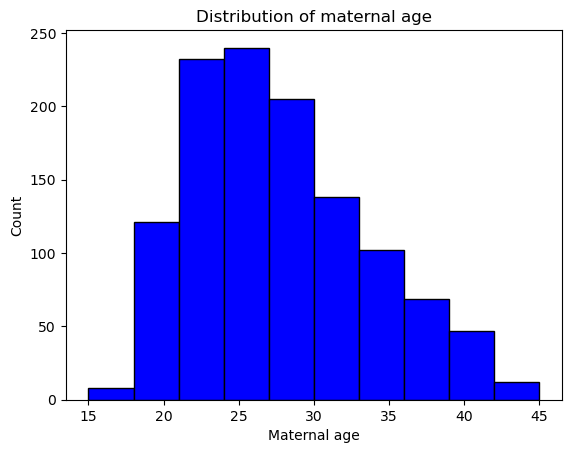

In [5]:
#Plotting a distribution of the ages of the maternal mothers in the sample dataset

plt.hist('Maternal Age', data = df, color = 'blue', ec = 'black')
plt.xlabel('Maternal age')
plt.ylabel('Count')
plt.title('Distribution of maternal age')

In [6]:
#Calculating the mean age of the maternal mothers in the sample using the mean() function

orig_sample_mean_age = df['Maternal Age'].mean()
orig_sample_mean_age

27.228279386712096

In [11]:
#Bootstrapping: Picking a resample from the original sample itself and calculating the mean age of the maternal mothers of that 
#resample

#Resample size must also be the same size as the original sample and resampling must be done with replacement to ensure that we
#do not pick the same original sample again

resample = df.sample(1174, replace = True)
resample_mean_age = resample['Maternal Age'].mean()
resample_mean_age

27.097955706984667

In [12]:
#Bootstrapping: Picking 10,000 resamples from the original sample itself and calculating the mean age of the maternal mothers 
#of each of the 10,000 resamples

repetitions = 10000

bootstraps = []

for i in np.arange(repetitions):
    resample = df.sample(1174, replace = True)
    resample_mean_age = resample['Maternal Age'].mean()
    bootstraps.append(resample_mean_age)
    
bootstraps = np.array(bootstraps)

Text(0.5, 1.0, 'Distribution of mean maternal age from 10000 resamples')

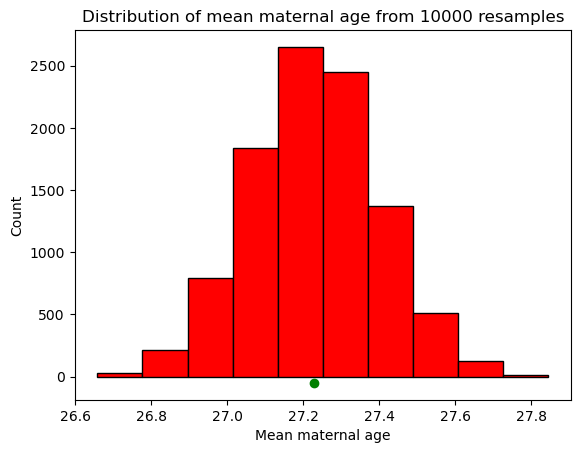

In [13]:
#Plotting a distribution of the mean age of the maternal mothers that we got out of 10,000 resamples

#Also, the mean age of the maternal mothers of the original sample is plotted to see if it is contained within the distribution 
#of the median total compensation values that we got out of 10,000 resamples 

plt.hist(bootstraps, color = 'red', ec = 'black')
plt.scatter(orig_sample_mean_age, -50, color = 'green')
plt.xlabel('Mean maternal age')
plt.ylabel('Count')
plt.title('Distribution of mean maternal age from 10000 resamples')

In [14]:
#Middle 95% interval range: Computing median values that correspond to percentile 2.5 and 97.5

left_95 = np.percentile(bootstraps, 2.5)
right_95 = np.percentile(bootstraps, 97.5)

print(left_95, right_95)

26.895229982964224 27.567291311754683


In [15]:
#Middle 80% interval range: Computing median values that correspond to percentile 10 and 90

left_80 = np.percentile(bootstraps, 10)
right_80 = np.percentile(bootstraps, 90)

print(left_80, right_80)

27.01022146507666 27.44718909710392


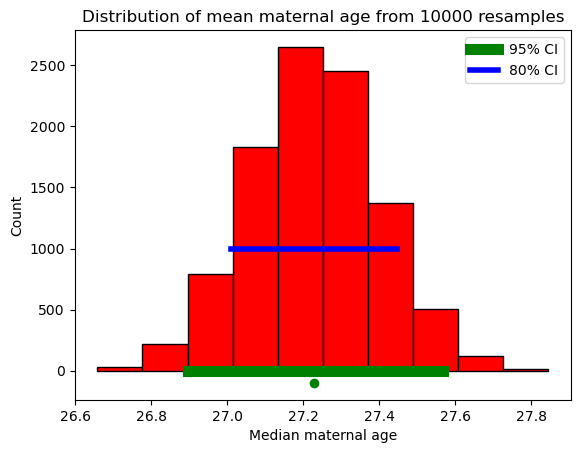

In [16]:
#Plotting a distribution of the mean age of the maternal mothers that we got out of 10,000 resamples

#Also, the mean age of the maternal mothers of the original sample is plotted to see if it is contained within the distribution 
#of the median total compensation values that we got out of 10,000 resamples 

#The middle 95% interval range (yellow line) and the middle 80% interval range (blue line) of the resampled median values is 
#also plotted

plt.hist(bootstraps, color = 'red', ec = 'black')
plt.scatter(orig_sample_mean_age, -100, color = 'green')
plt.plot([left_95, right_95], [0, 0], color = 'green', lw = 8, label = '95% CI')
plt.plot([left_80, right_80], [1000, 1000], color = 'blue', lw = 4, label = '80% CI')
plt.xlabel('Median maternal age')
plt.ylabel('Count')
plt.title('Distribution of mean maternal age from 10000 resamples')
plt.legend()